# Лабораторная работа №3
## Классификация временных рядов и прогнозирование метеоданных (6 городов)

Полный пайплайн по заданию:

1. **EDA** — качество данных, визуализации, корреляции, стационарность (ADF), пропуски  
2. **Инжиниринг признаков** — время, циклы sin/cos, лаги, скользящие статистики, производные, климатическая норма, PCA  
3. **Классификация** типа климата по окну дневного ряда (скользящие окна)  
4. **Прогноз** среднесуточной температуры на **30 дней** вперёд для каждого города (отдельные модели)  
5. **Двухэтапный пайплайн** — сначала климат, затем выбор городской модели внутри зоны и прогноз  

**Данные:** распакуйте `data.zip` в каталог `data/` (внутри появится папка `данные` с parquet-файлами).


## 0. Импорты и настройки

In [39]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid", font_scale=0.95)


## 1. Загрузка и дневной ресемплинг

In [40]:
CLIMATE_MAP = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "морской субтропический",
    "Геленджик": "морской субтропический",
    "Благовещенск": "дальневосточный",
    "Находка": "дальневосточный",
}

BASE_FEATURES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

DAILY_AGG = {
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "precipitation": "sum",
    "rain": "sum",
    "snowfall": "sum",
    "weathercode": "median",
    "wind_speed_10m": "mean",
    "surface_pressure": "mean",
}


def load_weather_data(data_dir: str | Path) -> pd.DataFrame:
    # Все *.parquet из data_dir рекурсивно (в т.ч. подпапка «данные»).
    data_dir = Path(data_dir)
    frames = []
    paths = sorted(data_dir.rglob("*.parquet"))
    for path in paths:
        stem = path.stem
        city = stem.split("_")[0]
        table = pq.read_table(path)
        df = table.to_pandas()
        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"])
            df = df.set_index("time").sort_index()
        df["city"] = city
        frames.append(df)

    if not frames:
        raise ValueError(f"В {data_dir} не найдено parquet-файлов (ожидается распакованный data.zip).")

    full = pd.concat(frames).sort_index()
    full["climate_type"] = full["city"].map(CLIMATE_MAP)
    if full["climate_type"].isna().any():
        bad = full.loc[full["climate_type"].isna(), "city"].unique()
        raise ValueError(f"Неизвестные города в файлах: {bad}. Добавьте их в CLIMATE_MAP.")
    return full


DATA_DIR = Path("data")
raw_df = load_weather_data(DATA_DIR)
print(raw_df.shape)
display(raw_df.head())

# Почасовые -> дневные агрегаты (единая частота для горизонта H=30 дней)
daily_df = (
    raw_df.groupby("city")
    .resample("D")
    .agg(DAILY_AGG)
    .reset_index()
    .sort_values(["city", "time"])
)
daily_df["climate_type"] = daily_df["city"].map(CLIMATE_MAP)
print("daily:", daily_df.shape)


(368208, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,climate_type
time,,,,,,,,,,
2019-01-01,-13.7,56,0.0,0.0,0.0,3,12.6,1008.700012,Благовещенск,дальневосточный
2019-01-01,-6.5,92,0.0,0.0,0.0,3,10.8,1000.500000,Москва,умеренно-континентальный
2019-01-01,-13.4,58,0.0,0.0,0.0,0,5.2,1025.500000,Находка,дальневосточный
2019-01-01,-1.8,85,0.0,0.0,0.0,3,23.5,1015.200012,Санкт-Петербург,умеренно-континентальный
2019-01-01,4.6,89,0.2,0.2,0.0,51,8.0,1024.699951,Сочи,морской субтропический


daily: (15342, 11)


## 2.1 EDA — обзор, пропуски, визуализации по городам

**Интерполяция:** для метеорядов умеренно заполнение пропусков линейной интерполяцией по времени внутри города (сохраняет плавность); при краевых пропусках — ffill/bfill.

**Выбросы:** экстремальные значения возможны при реальных погодных явлениях; жёсткое удаление не применяем — модели устойчивые к шуму (деревья) или сглаживание через агрегаты.

**Ресемплинг:** исходные ряды почасовые; для прогноза на месяц дневная частота снижает шум и задаёт однозначный горизонт в 30 суток.


,t_start,t_end,n_hourly,missing_total
city,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,0
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,0
Москва,2019-01-01,2025-12-31 23:00:00,61368,0
Находка,2019-01-01,2025-12-31 23:00:00,61368,0
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,0
Сочи,2019-01-01,2025-12-31 23:00:00,61368,0


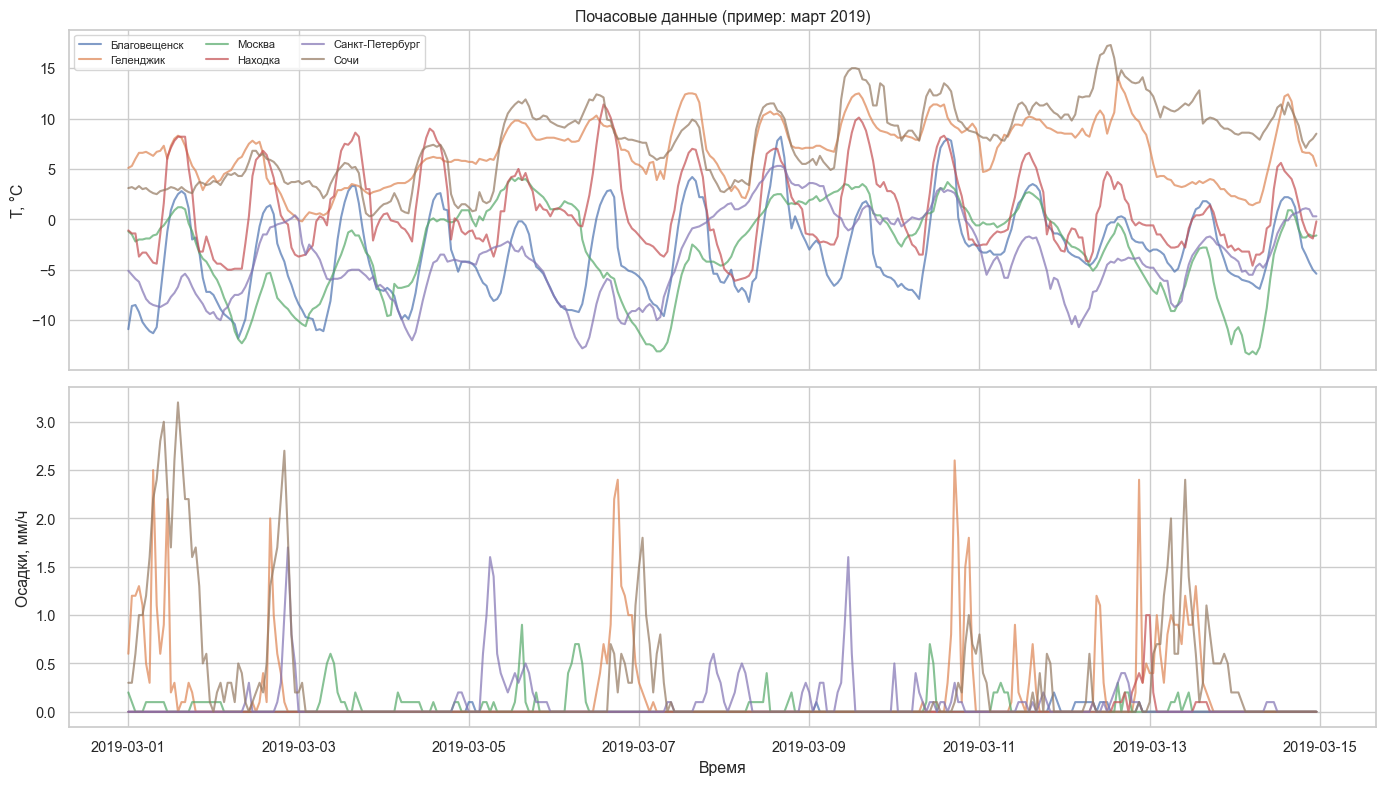

In [41]:
# Сводка по городам
miss = []
for city, g in raw_df.groupby("city"):
    miss.append({
        "city": city,
        "t_start": g.index.min(),
        "t_end": g.index.max(),
        "n_hourly": len(g),
        "missing_total": g[BASE_FEATURES].isna().sum().sum(),
    })
miss_df = pd.DataFrame(miss).set_index("city")
display(miss_df)

# Визуализация рядов (температура + осадки) — фрагмент для читаемости
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for city in sorted(raw_df["city"].unique()):
    sub = raw_df[raw_df["city"] == city]["2019-03-01":"2019-03-14"]
    axes[0].plot(sub.index, sub["temperature_2m"], alpha=0.7, label=city)
    axes[1].plot(sub.index, sub["precipitation"], alpha=0.7, label=city)
axes[0].set_ylabel("T, °C")
axes[0].legend(ncol=3, fontsize=8)
axes[0].set_title("Почасовые данные (пример: март 2019)")
axes[1].set_ylabel("Осадки, мм/ч")
axes[1].set_xlabel("Время")
plt.tight_layout()
plt.show()


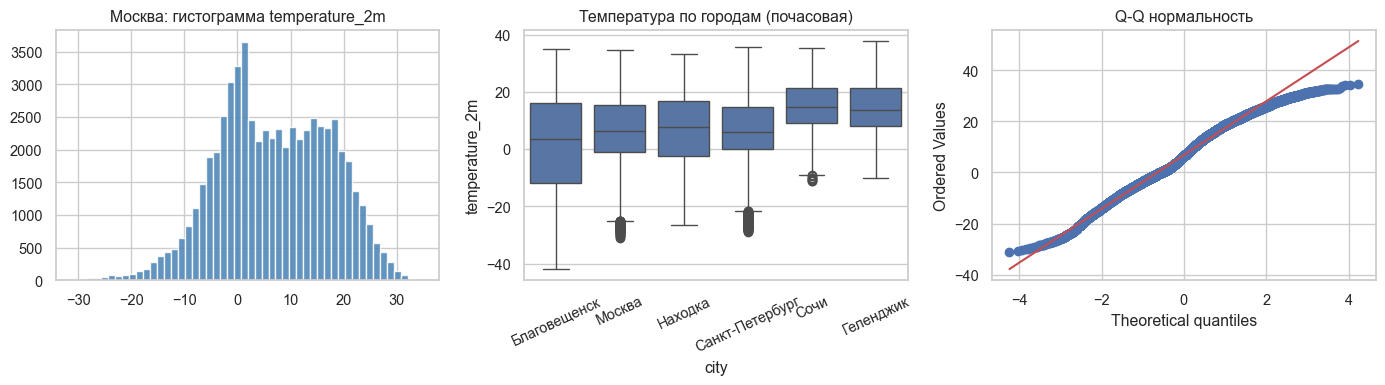

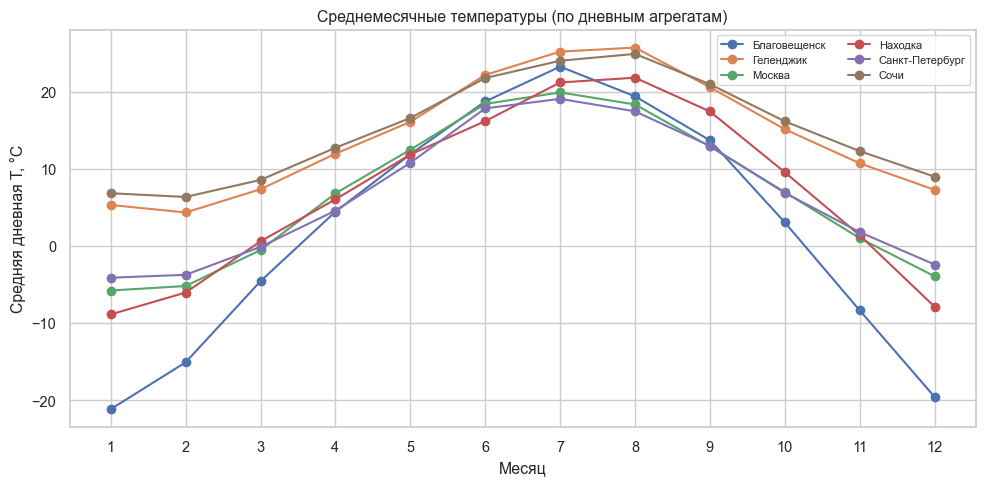

In [42]:
# Распределения и Q-Q (температура) для одного города + сравнение температур между городами
city_demo = "Москва"
col = "temperature_2m"
hourly_city = raw_df[raw_df["city"] == city_demo]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(hourly_city[col].dropna(), bins=50, color="steelblue", alpha=0.85)
axes[0].set_title(f"{city_demo}: гистограмма {col}")
sns.boxplot(data=raw_df.reset_index(), x="city", y=col, ax=axes[1])
axes[1].tick_params(axis="x", rotation=25)
axes[1].set_title("Температура по городам (почасовая)")
stats.probplot(hourly_city[col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("Q-Q нормальность")
plt.tight_layout()
plt.show()

# Среднемесячная температура (климатический профиль)
mprof = (
    daily_df.assign(month=daily_df["time"].dt.month)
    .groupby(["city", "month"])["temperature_2m"]
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10, 5))
for city in sorted(mprof["city"].unique()):
    sub = mprof[mprof["city"] == city]
    ax.plot(sub["month"], sub["temperature_2m"], marker="o", label=city)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Месяц")
ax.set_ylabel("Средняя дневная T, °C")
ax.legend(ncol=2, fontsize=8)
ax.set_title("Среднемесячные температуры (по дневным агрегатам)")
plt.tight_layout()
plt.show()


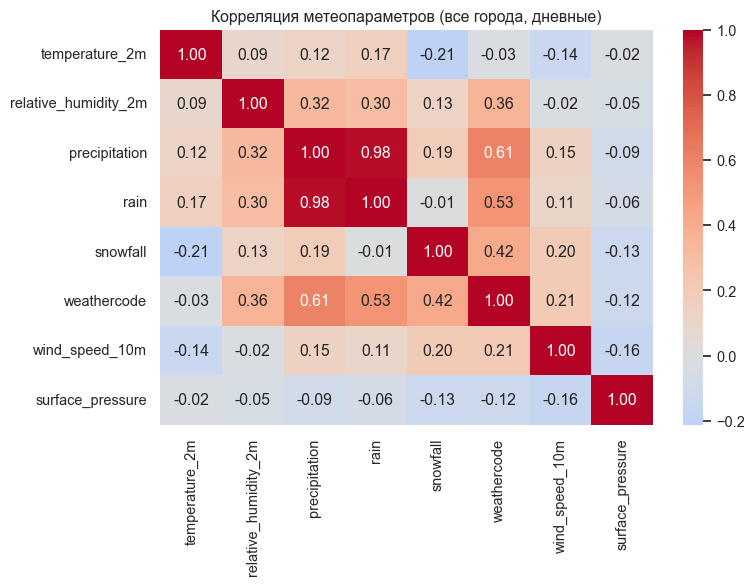

In [43]:
# Корреляции признаков (на дневных данных, объединённый датасет)
num_cols = [c for c in BASE_FEATURES if c in daily_df.columns]
corr = daily_df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляция метеопараметров (все города, дневные)")
plt.tight_layout()
plt.show()


In [44]:
# ADF-тест стационарности дневной температуры по городам


def adf_report(df: pd.DataFrame, col: str = "temperature_2m") -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        series = g.sort_values("time")[col].dropna()
        if len(series) < 30:
            continue
        stat, p, *_ = adfuller(series.values, autolag="AIC")
        rows.append({"city": city, "ADF_stat": stat, "p_value": p, "stationary_5pct": p < 0.05})
    return pd.DataFrame(rows)


adf_daily = adf_report(daily_df)
display(adf_daily)

# Дифференцирование (пример: Москва)
one = daily_df[daily_df["city"] == "Москва"].sort_values("time")["temperature_2m"]
diff1 = one.diff().dropna()
print("ADF после 1-го diff:", adfuller(diff1.values, autolag="AIC")[:2])


,city,ADF_stat,p_value,stationary_5pct
0,Благовещенск,-3.332754,0.013476,True
1,Геленджик,-3.010813,0.033897,True
2,Москва,-3.158227,0.022534,True
3,Находка,-2.846732,0.051902,False
4,Санкт-Петербург,-3.183499,0.020960,True
5,Сочи,-3.097536,0.026736,True


ADF после 1-го diff: (np.float64(-17.672603599188783), np.float64(3.638931961148433e-30))


**Выводы EDA (кратко):** ряды сезонны; распределения температуры близки к унимодальным, но хвосты тяжёлые; корреляции отражают физику (T vs давление и т.д.); стационарность в уровнях часто отвергается — для ML-прогноза используем признаки с лагами и трендами вместо голого ARIMA на уровнях.


## 2.2 Инжиниринг признаков (время, лаги, скольжение, производные, климатическая норма)

In [45]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["time"])
    out["hour"] = dt.dt.hour
    out["dayofweek"] = dt.dt.dayofweek
    out["day"] = dt.dt.day
    out["month"] = dt.dt.month
    out["quarter"] = dt.dt.quarter
    out["year"] = dt.dt.year
    out["dayofyear"] = dt.dt.dayofyear
    out["season"] = np.select(
        [
            out["month"].isin([12, 1, 2]),
            out["month"].isin([3, 4, 5]),
            out["month"].isin([6, 7, 8]),
            out["month"].isin([9, 10, 11]),
        ],
        ["winter", "spring", "summer", "autumn"],
        default="unknown",
    )
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["doy_sin"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)
    return out


def add_lag_features(df: pd.DataFrame, group_col: str, target_cols: list[str], lags: list[int]) -> pd.DataFrame:
    out = df.copy()
    for col in target_cols:
        for lag in lags:
            out[f"{col}_lag_{lag}"] = out.groupby(group_col)[col].shift(lag)
    return out


def add_rolling_features(df: pd.DataFrame, group_col: str, target_cols: list[str], windows: list[int]) -> pd.DataFrame:
    out = df.copy()
    for col in target_cols:
        for win in windows:
            grouped = out.groupby(group_col)[col]
            out[f"{col}_roll_mean_{win}"] = grouped.transform(lambda s: s.rolling(win).mean())
            out[f"{col}_roll_std_{win}"] = grouped.transform(lambda s: s.rolling(win).std())
            out[f"{col}_roll_min_{win}"] = grouped.transform(lambda s: s.rolling(win).min())
            out[f"{col}_roll_max_{win}"] = grouped.transform(lambda s: s.rolling(win).max())
    return out


daily_df = add_time_features(daily_df)

# Производные (по дням внутри города)
for c in ["temperature_2m", "surface_pressure"]:
    daily_df[f"{c}_vel"] = daily_df.groupby("city")[c].diff()
daily_df["temperature_2m_acc"] = daily_df.groupby("city")["temperature_2m_vel"].diff()

daily_features_df = add_lag_features(
    daily_df,
    group_col="city",
    target_cols=["temperature_2m", "precipitation", "surface_pressure", "wind_speed_10m"],
    lags=[1, 3, 7, 14, 30],
)
daily_features_df = add_rolling_features(
    daily_features_df,
    group_col="city",
    target_cols=["temperature_2m", "precipitation", "surface_pressure"],
    windows=[3, 7, 14, 30],
)

clim_norm = (
    daily_features_df.groupby(["city", "dayofyear"])["temperature_2m"]
    .mean()
    .rename("temperature_clim_norm")
    .reset_index()
)
daily_features_df = daily_features_df.merge(clim_norm, on=["city", "dayofyear"], how="left")
daily_features_df["temperature_anomaly"] = daily_features_df["temperature_2m"] - daily_features_df["temperature_clim_norm"]

display(daily_features_df.head(2))


,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,surface_pressure_roll_mean_14,surface_pressure_roll_std_14,surface_pressure_roll_min_14,surface_pressure_roll_max_14,surface_pressure_roll_mean_30,surface_pressure_roll_std_30,surface_pressure_roll_min_30,surface_pressure_roll_max_30,temperature_clim_norm,temperature_anomaly
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.332142,7.294642
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21.717260,3.325594


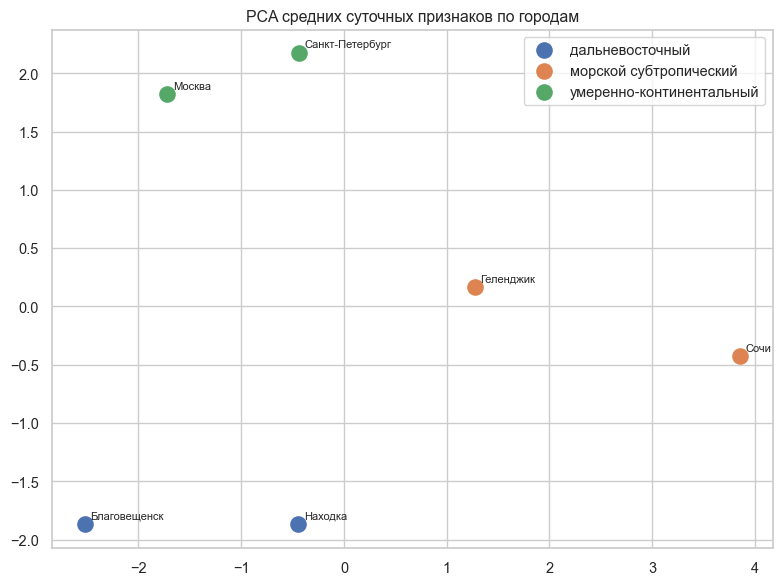

Доля дисперсии PC1+PC2: 0.8620507150277211


In [46]:
# PCA для визуализации разделимости городов (по суточным признакам без лагов — укороченный вектор)
pca_cols = [c for c in BASE_FEATURES if c in daily_features_df.columns]
pca_mat = daily_features_df.groupby("city")[pca_cols].mean()
scaler_pca = StandardScaler()
Z = scaler_pca.fit_transform(pca_mat.values)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
xy = pca.fit_transform(Z)
pca_df = pd.DataFrame({"PC1": xy[:, 0], "PC2": xy[:, 1], "city": pca_mat.index})
pca_df["climate"] = pca_df["city"].map(CLIMATE_MAP)
fig, ax = plt.subplots(figsize=(8, 6))
for cl in pca_df["climate"].unique():
    sub = pca_df[pca_df["climate"] == cl]
    ax.scatter(sub["PC1"], sub["PC2"], label=cl, s=120)
for _, r in pca_df.iterrows():
    ax.annotate(r["city"], (r["PC1"], r["PC2"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_title("PCA средних суточных признаков по городам")
ax.legend()
plt.tight_layout()
plt.show()
print("Доля дисперсии PC1+PC2:", float(pca.explained_variance_ratio_.sum()))


**Обоснование окон:** лаги 1–30 суток отражают инерцию погоды от синоптического дня до месячного фона; скользящие 3–30 дней — локальную и сглаженную изменчивость, согласованную с горизонтом прогноза 30 дней.


## 2.3–2.4 Классификация типа климата

**Почему не «наивные» модели:** линейный SVM на сырых уровнях без агрегатов окна плохо улавливает нелинейные режимы; чистый k-NN в высокой размерности чувствителен к масштабу (лечится, но RF устойчивее к выбросам).

**Сложность задачи:** два города одного климата ближе друг к другу, чем к третьей зоне — нужны статистики окна, а не мгновенное значение.

Используем **RandomForest** на агрегированных признаках **окна 30 дней**, шаг **15 дней**; разделение по годам старта окна: train ≤2023, val 2024, test 2025.


Accuracy val/test: 0.94 0.7575757575757576
Precision macro/weighted: 0.8103371173030616 0.8103371173030617
Recall macro/weighted: 0.7575757575757575 0.7575757575757576
F1 macro test: 0.7385485405148327
F1 weighted test: 0.7385485405148327
                          precision    recall  f1-score   support

         дальневосточный      0.603     0.932     0.732        44
  морской субтропический      0.933     0.955     0.944        44
умеренно-континентальный      0.895     0.386     0.540        44

                accuracy                          0.758       132
               macro avg      0.810     0.758     0.739       132
            weighted avg      0.810     0.758     0.739       132



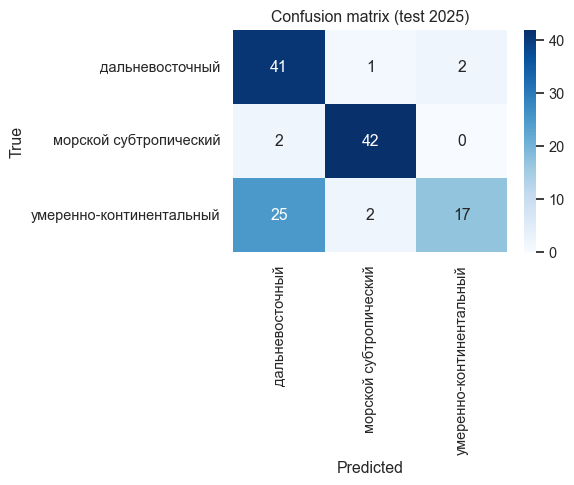

ROC-AUC OvR (macro): 0.9405


,importance
surface_pressure_min,0.134470
wind_speed_10m_mean,0.021780
surface_pressure_std,0.019886
surface_pressure_mean,0.013258
surface_pressure_max,0.008523
rain_max,0.005682
relative_humidity_2m_max,0.004735
precipitation_max,0.004735
snowfall_max,0.003788
temperature_2m_mean,0.002841


Accuracy по сезону окна:
 season_start
autumn    0.777778
spring    0.777778
summer    0.777778
winter    0.666667
Name: correct, dtype: float64


In [47]:
def safe_trend(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 2 or np.all(np.isnan(values)):
        return 0.0
    x = np.arange(len(values))
    try:
        return float(np.polyfit(x, values, 1)[0])
    except Exception:
        return 0.0


def build_classification_windows(df: pd.DataFrame, window: int = 30, step: int = 15) -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        g = g.sort_values("time").reset_index(drop=True)
        for start in range(0, len(g) - window + 1, step):
            w = g.iloc[start : start + window]
            row = {
                "city": city,
                "climate_type": w["climate_type"].iloc[0],
                "start_time": w["time"].iloc[0],
                "end_time": w["time"].iloc[-1],
                "month": int(w["time"].dt.month.mode().iloc[0]),
                "season": w["season"].mode().iloc[0],
            }
            for col in [
                "temperature_2m",
                "relative_humidity_2m",
                "precipitation",
                "rain",
                "snowfall",
                "wind_speed_10m",
                "surface_pressure",
            ]:
                values = w[col].values
                row[f"{col}_mean"] = np.mean(values)
                row[f"{col}_std"] = np.std(values)
                row[f"{col}_min"] = np.min(values)
                row[f"{col}_max"] = np.max(values)
                row[f"{col}_trend"] = safe_trend(values)
            row["temp_amplitude"] = w["temperature_2m"].max() - w["temperature_2m"].min()
            row["wet_days_share"] = float((w["precipitation"] > 0).mean())
            row["max_wind_gust_proxy"] = float(w["wind_speed_10m"].max())
            row["mean_temp"] = float(w["temperature_2m"].mean())
            row["std_temp"] = float(w["temperature_2m"].std())
            rows.append(row)
    return pd.DataFrame(rows)


clf_df = build_classification_windows(daily_features_df, window=30, step=15)
clf_df = pd.get_dummies(clf_df, columns=["season"], drop_first=False)

train_clf = clf_df[clf_df["start_time"].dt.year <= 2023].copy()
val_clf = clf_df[clf_df["start_time"].dt.year == 2024].copy()
test_clf = clf_df[clf_df["start_time"].dt.year == 2025].copy()

drop_cols = ["city", "climate_type", "start_time", "end_time"]
feature_cols_clf = [c for c in clf_df.columns if c not in drop_cols]

X_train_clf, y_train_clf = train_clf[feature_cols_clf], train_clf["climate_type"]
X_val_clf, y_val_clf = val_clf[feature_cols_clf], val_clf["climate_type"]
X_test_clf, y_test_clf = test_clf[feature_cols_clf], test_clf["climate_type"]

clf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)
clf_pipe.fit(X_train_clf, y_train_clf)

val_pred = clf_pipe.predict(X_val_clf)
clf_test_pred = clf_pipe.predict(X_test_clf)
clf_test_proba = clf_pipe.predict_proba(X_test_clf)

labels = clf_pipe.named_steps["model"].classes_
print("Accuracy val/test:", accuracy_score(y_val_clf, val_pred), accuracy_score(y_test_clf, clf_test_pred))
print("Precision macro/weighted:", precision_score(y_test_clf, clf_test_pred, average="macro", zero_division=0), precision_score(y_test_clf, clf_test_pred, average="weighted", zero_division=0))
print("Recall macro/weighted:", recall_score(y_test_clf, clf_test_pred, average="macro", zero_division=0), recall_score(y_test_clf, clf_test_pred, average="weighted", zero_division=0))
print("F1 macro test:", f1_score(y_test_clf, clf_test_pred, average="macro"))
print("F1 weighted test:", f1_score(y_test_clf, clf_test_pred, average="weighted"))
print(classification_report(y_test_clf, clf_test_pred, digits=3))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_clf, clf_test_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues", ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test 2025)")
plt.tight_layout()
plt.show()

# ROC-AUC OvR
Y_te = label_binarize(y_test_clf, classes=list(labels))
auc = roc_auc_score(Y_te, clf_test_proba, multi_class="ovr", average="macro")
print("ROC-AUC OvR (macro):", round(auc, 4))

# Permutation importance (на подвыборке для скорости)
r = permutation_importance(
    clf_pipe, X_test_clf, y_test_clf, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1
)
imp = pd.Series(r.importances_mean, index=feature_cols_clf).sort_values(ascending=False).head(15)
display(imp.to_frame("importance"))

# Ошибки по сезону старта окна (колонка season заменена на dummies — сезон по start_time)
m = test_clf["start_time"].dt.month
season_start = np.select(
    [m.isin([12, 1, 2]), m.isin([3, 4, 5]), m.isin([6, 7, 8]), m.isin([9, 10, 11])],
    ["winter", "spring", "summer", "autumn"],
    default="unknown",
)
test_clf = test_clf.assign(pred=clf_test_pred, correct=clf_test_pred == y_test_clf.values, season_start=season_start)
season_acc = test_clf.groupby("season_start")["correct"].mean()
print("Accuracy по сезону окна:\n", season_acc)


## 2.5–2.6 Модели прогнозирования (H=30 дней, история 30 дней)

Для каждого города выбирается лучшая из трёх схем по валидации 2024: Ridge multi-output, RandomForest, ExtraTrees.  
Train: окна до 2023, val: 2024, test: 2025.

**Почему разные модели по зонам:** субтропики (Сочи/Геленджик) — более выраженная нелинейность осадков/Т; континентальные центры — более предсказуемый сезонный фон; деревья часто выигрывают на валидации, но Ridge может быть сильнее при малом шуме.

**Что плохо для месячного горизонта:** наивный сезонный наивный прогноз без признаков; чистый AR(1) без внешних признаков — недостаточная размерность для 30 шагов.


In [48]:
FORECAST_BASE_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "surface_pressure",
]


def build_forecast_dataset(
    city_df: pd.DataFrame,
    target: str = "temperature_2m",
    history: int = 30,
    horizon: int = 30,
):
    city_df = city_df.sort_values("time").reset_index(drop=True).copy()
    rows, targets, meta = [], [], []
    for i in range(history, len(city_df) - horizon + 1):
        hist = city_df.iloc[i - history : i]
        current = city_df.iloc[i]
        feat = {}
        for col in FORECAST_BASE_COLS:
            values = hist[col].values
            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)
        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]
        feat["temperature_clim_norm"] = current.get("temperature_clim_norm", np.nan)
        feat["temperature_anomaly"] = current.get("temperature_anomaly", np.nan)
        rows.append(feat)
        targets.append(city_df[target].iloc[i : i + horizon].values)
        meta.append(city_df["time"].iloc[i])
    X = pd.DataFrame(rows)
    y = np.vstack(targets)
    meta = pd.Series(meta, name="forecast_start")
    return X, y, meta


def temporal_split(X: pd.DataFrame, y: np.ndarray, meta: pd.Series):
    years = pd.to_datetime(meta).dt.year
    train_idx = years <= 2023
    val_idx = years == 2024
    test_idx = years == 2025
    return (
        X.loc[train_idx].reset_index(drop=True),
        X.loc[val_idx].reset_index(drop=True),
        X.loc[test_idx].reset_index(drop=True),
        y[train_idx.values],
        y[val_idx.values],
        y[test_idx.values],
        meta.loc[train_idx].reset_index(drop=True),
        meta.loc[val_idx].reset_index(drop=True),
        meta.loc[test_idx].reset_index(drop=True),
    )


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape_safe(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)


def wape(y_true, y_pred, eps=1e-6):
    num = np.abs(y_true - y_pred).sum()
    den = np.abs(y_true).sum()
    return float(num / (den if den > eps else eps) * 100)


def direction_accuracy(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true, axis=1))
    pred_dir = np.sign(np.diff(y_pred, axis=1))
    return float((true_dir == pred_dir).mean())


candidate_models = {
    "ridge_multioutput": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MultiOutputRegressor(Ridge(alpha=3.0))),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                max_depth=12,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
    "extra_trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=300,
                max_depth=14,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
}

city_model_results = []
best_models = {}
forecast_test_store = {}

for city in sorted(daily_features_df["city"].unique()):
    city_df = daily_features_df[daily_features_df["city"] == city].copy()
    X, y, meta = build_forecast_dataset(city_df, target="temperature_2m", history=30, horizon=30)
    X_train, X_val, X_test, y_train, y_val, y_test, meta_train, meta_val, meta_test = temporal_split(X, y, meta)

    best_name, best_val_mae, best_model = None, np.inf, None
    for model_name, model in candidate_models.items():
        fitted = clone(model)
        fitted.fit(X_train, y_train)
        val_pred = fitted.predict(X_val)
        val_mae = mean_absolute_error(y_val.ravel(), val_pred.ravel())
        city_model_results.append({
            "city": city,
            "model": model_name,
            "split": "val",
            "MAE": val_mae,
            "RMSE": rmse(y_val.ravel(), val_pred.ravel()),
            "MAPE": mape_safe(y_val.ravel(), val_pred.ravel()),
            "WAPE": wape(y_val.ravel(), val_pred.ravel()),
        })
        if val_mae < best_val_mae:
            best_val_mae, best_name, best_model = val_mae, model_name, fitted

    fc_test_pred = best_model.predict(X_test)
    best_models[city] = {"name": best_name, "model": best_model, "feature_columns": X.columns.tolist()}
    forecast_test_store[city] = {"X_test": X_test, "y_test": y_test, "pred_test": fc_test_pred, "meta_test": meta_test}
    city_model_results.append({
        "city": city,
        "model": best_name,
        "split": "test",
        "MAE": mean_absolute_error(y_test.ravel(), fc_test_pred.ravel()),
        "RMSE": rmse(y_test.ravel(), fc_test_pred.ravel()),
        "MAPE": mape_safe(y_test.ravel(), fc_test_pred.ravel()),
        "WAPE": wape(y_test.ravel(), fc_test_pred.ravel()),
        "Direction_Accuracy": direction_accuracy(y_test, fc_test_pred),
    })

forecast_metrics_df = pd.DataFrame(city_model_results)
display(forecast_metrics_df[forecast_metrics_df["split"] == "test"].sort_values("MAE"))


,city,model,split,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
23,Сочи,ridge_multioutput,test,2.424687,3.232259,40.471143,15.932453,0.524323
15,Находка,ridge_multioutput,test,2.462092,3.230768,79.504461,21.029337,0.535304
3,Благовещенск,extra_trees,test,2.840372,3.764857,54.548358,20.385998,0.537869
7,Геленджик,ridge_multioutput,test,2.864576,3.744295,85.639354,19.179445,0.525349
19,Санкт-Петербург,ridge_multioutput,test,3.040533,3.800418,194.663186,32.576371,0.532738
11,Москва,extra_trees,test,4.013180,4.824134,277.693866,39.028333,0.521039


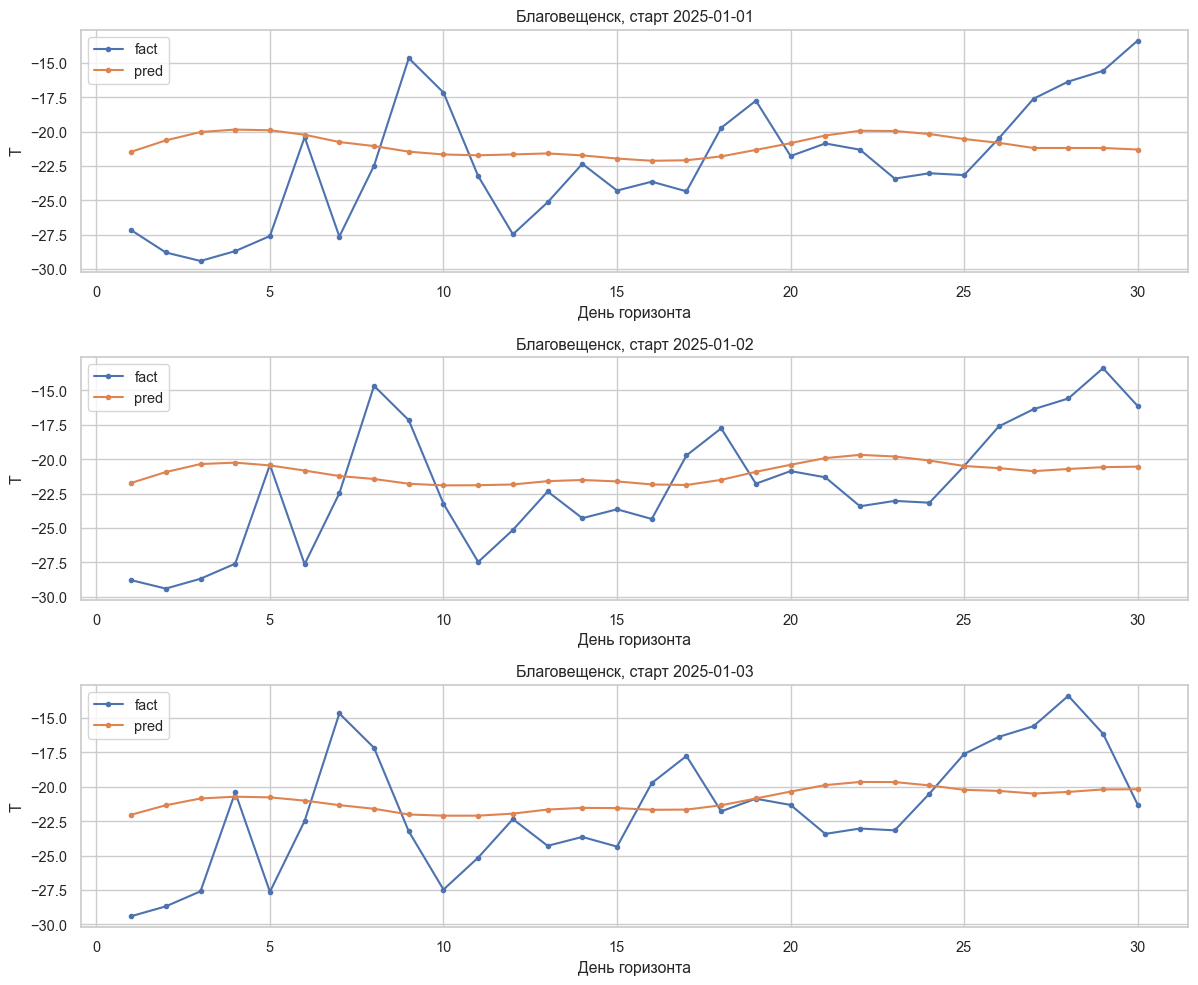

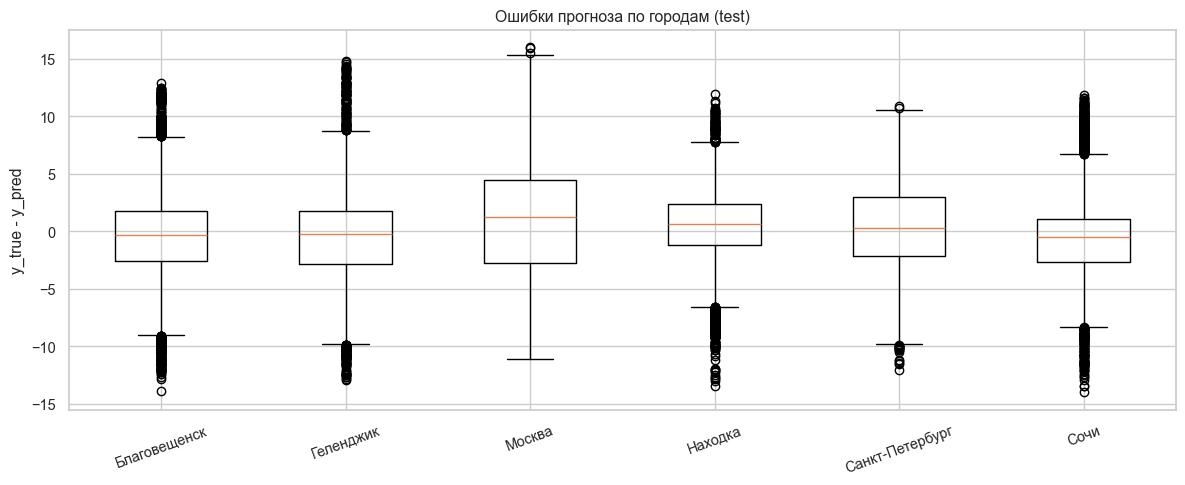

In [49]:
# Визуализация: один город — факт vs прогноз на тесте (первые 3 окна)
demo_city = sorted(forecast_test_store.keys())[0]
store = forecast_test_store[demo_city]
y_t, p_t, m_t = store["y_test"], store["pred_test"], store["meta_test"]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
for k in range(3):
    axes[k].plot(range(1, 31), y_t[k], label="fact", marker="o", ms=3)
    axes[k].plot(range(1, 31), p_t[k], label="pred", marker="o", ms=3)
    axes[k].set_title(f"{demo_city}, старт {pd.to_datetime(m_t.iloc[k]).date()}")
    axes[k].set_xlabel("День горизонта")
    axes[k].set_ylabel("T")
    axes[k].legend()
plt.tight_layout()
plt.show()

# Boxplot ошибок по городам
errs, labels_box = [], []
for city, store in forecast_test_store.items():
    errs.append((store["y_test"] - store["pred_test"]).ravel())
    labels_box.append(city)
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(errs, tick_labels=labels_box)
ax.set_title("Ошибки прогноза по городам (test)")
ax.set_ylabel("y_true - y_pred")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [50]:
# Анализ остатков (объединённый тест): Шапиро, Льюнг-Бокс на ACF, Уайт на квадраты остатков vs константа

residuals = np.concatenate([(s["y_test"] - s["pred_test"]).ravel() for s in forecast_test_store.values()])
residuals = residuals[np.isfinite(residuals)]
print("N residuals:", len(residuals))
if len(residuals) > 5000:
    rng = np.random.default_rng(RANDOM_STATE)
    residuals = rng.choice(residuals, size=5000, replace=False)

_, p_shapiro = stats.shapiro(residuals)
print("Shapiro p-value:", p_shapiro)

lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
print("Ljung-Box:\n", lb)

# Тест Уайта: остатки вспомогательной регрессии oстатков ~ время
e = residuals[:2000].copy()
t = np.arange(len(e), dtype=float)
ols_aux = sm.OLS(e, sm.add_constant(t)).fit()
try:
    _, p_white, _, _ = het_white(ols_aux.resid, ols_aux.model.exog)
    print("White p-value (остатки aux OLS):", p_white)
except Exception as ex:
    print("White test skipped:", ex)


N residuals: 60480
Shapiro p-value: 2.1105714307591603e-08
Ljung-Box:
     lb_stat  lb_pvalue
10  5.15039   0.880908
White p-value (остатки aux OLS): 0.6339180557143748


## 2.7 Двухэтапный пайплайн

In [51]:
city_prototypes = (
    clf_df.groupby("city")[[c for c in clf_df.columns if c not in ["city", "climate_type", "start_time", "end_time"]]]
    .mean()
)


class TwoStageWeatherPipeline:
    def __init__(self, classifier, city_models, city_prototypes, climate_map):
        self.classifier = classifier
        self.city_models = city_models
        self.city_prototypes = city_prototypes
        self.climate_map = climate_map

    def _build_classification_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        tmp = recent_daily_window.copy().sort_values("time")
        tmp["climate_type"] = "unknown"
        tmp["season"] = np.select(
            [
                tmp["month"].isin([12, 1, 2]),
                tmp["month"].isin([3, 4, 5]),
                tmp["month"].isin([6, 7, 8]),
                tmp["month"].isin([9, 10, 11]),
            ],
            ["winter", "spring", "summer", "autumn"],
            default="unknown",
        )
        feats = build_classification_windows(tmp, window=len(tmp), step=len(tmp))
        feats = pd.get_dummies(feats, columns=["season"], drop_first=False)
        for col in feature_cols_clf:
            if col not in feats.columns:
                feats[col] = 0
        return feats[feature_cols_clf]

    def _guess_city_within_climate(self, feature_vector: pd.DataFrame, predicted_climate: str) -> str:
        candidate_cities = [c for c, cl in self.climate_map.items() if cl == predicted_climate]
        cols = [c for c in self.city_prototypes.columns if c in feature_vector.columns]
        prototype_space = self.city_prototypes.loc[candidate_cities, cols]
        vec = feature_vector[cols].iloc[0].values.astype(float)
        distances = {c: np.linalg.norm(vec - prototype_space.loc[c].values.astype(float)) for c in candidate_cities}
        return min(distances, key=distances.get)

    def _build_forecast_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        hist = recent_daily_window.copy().sort_values("time").reset_index(drop=True)
        hist = add_time_features(hist)
        feat = {}
        for col in FORECAST_BASE_COLS:
            values = hist[col].values
            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)
        current = hist.iloc[-1]
        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]
        dayofyear = int(current["dayofyear"])
        city = hist["city"].iloc[-1] if "city" in hist.columns else None
        if city is not None:
            nv = clim_norm[(clim_norm["city"] == city) & (clim_norm["dayofyear"] == dayofyear)]["temperature_clim_norm"]
            norm_value = float(nv.iloc[0]) if len(nv) else np.nan
        else:
            norm_value = np.nan
        feat["temperature_clim_norm"] = norm_value
        feat["temperature_anomaly"] = current["temperature_2m"] - norm_value if pd.notna(norm_value) else np.nan
        return pd.DataFrame([feat])

    def predict(self, recent_daily_window: pd.DataFrame, city: str | None = None) -> dict:
        if len(recent_daily_window) < 30:
            raise ValueError("Нужно не менее 30 дней дневных данных")
        recent = recent_daily_window.sort_values("time").tail(30).copy()
        clf_features = self._build_classification_features(recent)
        predicted_climate = self.classifier.predict(clf_features)[0]
        inferred_city = city
        if inferred_city is None:
            inferred_city = self._guess_city_within_climate(clf_features, predicted_climate)
        forecast_features = self._build_forecast_features(recent.assign(city=inferred_city))
        model_bundle = self.city_models[inferred_city]
        forecast = model_bundle["model"].predict(forecast_features)[0]
        start_date = pd.to_datetime(recent["time"].max()) + pd.Timedelta(days=1)
        forecast_dates = pd.date_range(start_date, periods=len(forecast), freq="D")
        return {
            "predicted_climate_type": predicted_climate,
            "selected_city_model": inferred_city,
            "model_name": model_bundle["name"],
            "forecast": pd.DataFrame({"date": forecast_dates, "temperature_forecast": forecast}),
        }


two_stage_pipeline = TwoStageWeatherPipeline(
    classifier=clf_pipe,
    city_models=best_models,
    city_prototypes=city_prototypes,
    climate_map=CLIMATE_MAP,
)

demo_city = "Москва"
demo_window = daily_features_df[daily_features_df["city"] == demo_city].sort_values("time").tail(30)
demo_result = two_stage_pipeline.predict(demo_window, city=demo_city)
print(demo_result["predicted_climate_type"], demo_result["model_name"])
display(demo_result["forecast"].head())


дальневосточный extra_trees


,date,temperature_forecast
0,2026-01-01,-5.209413
1,2026-01-02,-5.502015
2,2026-01-03,-5.623059
3,2026-01-04,-5.639879
4,2026-01-05,-5.977274


## 2.8 Итоговая сводка

Двухэтапная схема позволяет сначала унифицировать выбор семейства моделей по типу климата (полезно, если город «неизвестен»), затем применить уже обученный городской регрессор. Ограничение: качество классификации между городами одной зоны напрямую влияет на выбор модели — при известном городе лучше передавать `city=` явно.


In [52]:
summary_clf = pd.DataFrame([{
    "task": "classification climate_type",
    "accuracy_test": accuracy_score(y_test_clf, clf_test_pred),
    "f1_macro": f1_score(y_test_clf, clf_test_pred, average="macro"),
    "roc_auc_ovr": roc_auc_score(label_binarize(y_test_clf, classes=list(labels)), clf_test_proba, multi_class="ovr", average="macro"),
}])
summary_fc = forecast_metrics_df[forecast_metrics_df["split"] == "test"].copy()
print("Classification:")
display(summary_clf)
print("Forecasting (per city):")
display(summary_fc[["city", "model", "MAE", "RMSE", "MAPE", "WAPE", "Direction_Accuracy"]])


Classification:


,task,accuracy_test,f1_macro,roc_auc_ovr
0,classification climate_type,0.757576,0.738549,0.940513


Forecasting (per city):


,city,model,MAE,RMSE,MAPE,WAPE,Direction_Accuracy
3,Благовещенск,extra_trees,2.840372,3.764857,54.548358,20.385998,0.537869
7,Геленджик,ridge_multioutput,2.864576,3.744295,85.639354,19.179445,0.525349
11,Москва,extra_trees,4.013180,4.824134,277.693866,39.028333,0.521039
15,Находка,ridge_multioutput,2.462092,3.230768,79.504461,21.029337,0.535304
19,Санкт-Петербург,ridge_multioutput,3.040533,3.800418,194.663186,32.576371,0.532738
23,Сочи,ridge_multioutput,2.424687,3.232259,40.471143,15.932453,0.524323
